In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

Data Creation of Income

Text(0, 0.5, 'Frequency')

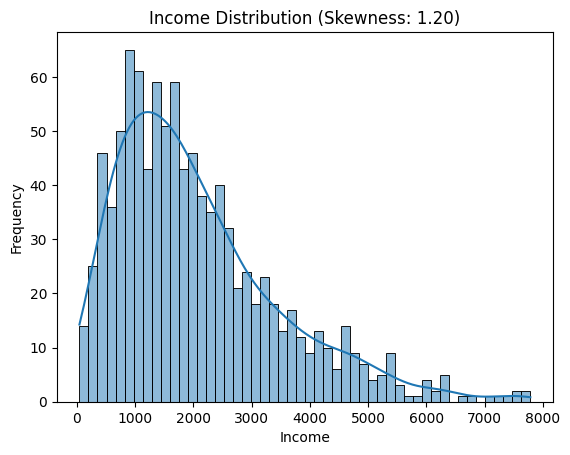

In [4]:
np.random.seed(42)

#Gamma helps to create right skewed distributions
income_distribution = np.random.gamma(shape=2.0, scale=1000.0, size=1000)

#Calculate the skewness
skew_value = skew(income_distribution)

sns.histplot(income_distribution, bins=50, kde=True)
plt.title(f'Income Distribution (Skewness: {skew_value:.2f})')
plt.xlabel('Income')
plt.ylabel('Frequency')

In [5]:
data = pd.read_csv('process_engineering_data_lyst1750493214144.csv')
data.head()

,process_id,temperature,pressure,flow_rate
0,26bac532-89b5-493d-94cb-3d5dda8f425c,52.483571,127.987109,26.624109
1,08e6adcb-f775-4d17-b129-e24ba29ee93d,49.308678,118.492674,29.277407
2,74d101ae-d735-4a90-b512-c836c7fa7ec5,53.238443,101.192607,26.037900
3,25ac6436-4f7c-4002-80ed-c31906434f38,57.615149,87.061264,28.460192
4,2fdcad4c-cf71-4606-a457-cab5e04fe203,48.829233,113.964466,20.531927


Calculate the range of the temperature columnin the above data

In [6]:
temperature_range = data['temperature'].max() - data['temperature'].min()
print(f"Range: {temperature_range}")

Range: 35.46999415361897


IQR (Inter-Quartile Range)

In [7]:
Q1 = data['temperature'].quantile(0.25)
Q3 = data['temperature'].quantile(0.75)

temprature_IQR = Q3-Q1
print(f"IQR: {temprature_IQR}")

IQR: 6.477670904676408


Varience of the pressure column

In [8]:
pressure_varience = data['pressure'].var()
print(f"Varience: {pressure_varience}")

Varience: 397.96609386005684


Standard Deviation (SD) of the pressure column

In [9]:
pressure_SD = data['pressure'].std()
print(f"Standard Deviation : {pressure_SD}")

Standard Deviation : 19.94908754454842


Use Case: Evaluate the kurtosis of the protfolio returns over the past year and what does that signify. Plus,you have to do the implementation corresponding to it.

In [11]:
np.random.seed(42)

days = 252
stocks = 5
stock_names = ["Stock_A","Stock_B","Stock_C","Stock_D","Stock_E"]
initial_price = 100
initial_prices = np.array([100, 120, 80, 150, 200])
mu = np.array([0.08, 0.10, 0.12, 0.09, 0.14])
sigma = np.array([0.15, 0.20, 0.25, 0.18, 0.30])
dt = 1/252

dates = pd.bdate_range(start='2026-01-01', periods=days)

Z = np.random.normal(loc=0, scale=1, size=(days, stocks))

prices = np.zeros((days, stocks))
prices[0] = initial_price

for t in range(1, days):
    drift = (mu - 0.5 * sigma**2)* dt
    shock = sigma * np.sqrt(dt) * Z[t]
    growth_factor = np.exp(drift + shock)
    prices[t] = prices[t-1] * growth_factor
    
price_df = pd.DataFrame(
    prices,
    index=dates,
    columns=stock_names
)

print(price_df.head())
price_df.to_csv("simulated_stock_prices.csv")


               Stock_A     Stock_B     Stock_C     Stock_D     Stock_E
2026-01-01  100.000000  100.000000  100.000000  100.000000  100.000000
2026-01-02   99.806231  102.041935  101.251582   99.498215  101.068711
2026-01-05   99.397260  101.477152  101.673943   97.391409   97.864091
2026-01-06   98.897529  100.222294  102.214360   96.422043   95.322573
2026-01-07  100.304057   99.969347  102.359162   94.904637   94.382508


In [12]:
# Daily returns
returns = price_df.pct_change().dropna()

# Portfolio weights
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

# Portfolio returns
portfolio_returns = returns.dot(weights)

print(portfolio_returns.head())

2026-01-02    0.007333
2026-01-05   -0.011669
2026-01-06   -0.009600
2026-01-07   -0.002497
2026-01-08   -0.003618
Freq: B, dtype: float64


In [13]:
kurtosis_value = portfolio_returns.kurt()

print("Portfolio Kurtosis:", kurtosis_value)

Portfolio Kurtosis: -0.2852058481112483
